In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import os
import pandas as pd
import glob

# 定义基础路径
base_path = 'C:/Users/snong/Desktop/remote_data/green/'

# 自动获取目录下所有的 CSV 文件
# 假设该目录下只有一个你要处理的 csv 文件
search_pattern = os.path.join(base_path, '*.csv')
found_files = glob.glob(search_pattern)

if not found_files:
    print(f"⚠️ 警告: 在 {base_path} 目录下没有找到任何 CSV 文件！")
else:
    # 直接获取找到的第一个文件
    file_path = found_files[0]
    file_name = os.path.basename(file_path)
    print(f"正在处理唯一找到的文件: {file_name} ...")

    all_parsed_rows = []
    current_date, current_time, current_offset = "", "", ""
    
    try:
        with open(file_path, 'r', encoding='utf-8') as file:
            for line in file:
                line = line.strip()
                
                # 忽略空行和 '}'
                if not line or line == '}':
                    continue
                
                # 提取时间戳逻辑
                if ',' in line:
                    parts = line.split(',', 3)
                    current_date = parts[0].strip() if len(parts) > 0 else ""
                    current_time = parts[1].strip() if len(parts) > 1 else ""
                    current_offset = parts[2].strip() if len(parts) > 2 else ""
                    # 增加健壮性，防止某些行只有逗号没有数据
                    data_part = parts[3].strip() if len(parts) > 3 else "" 
                else:
                    data_part = line
                    
                row_dict = {
                    'File_Source': file_name,  # 添加文件来源标识
                    'Date': current_date,
                    'Time': current_time,
                    'Duration': current_offset
                }
                
                # 提取各个传感器数据
                if data_part:
                    kv_pairs = data_part.split(';')
                    for kv in kv_pairs:
                        if ':' in kv:
                            key, value = kv.split(':', 1)
                            row_dict[key.strip()] = value.strip()
                            
                    all_parsed_rows.append(row_dict)
                    
    except Exception as e:
        print(f"读取文件时发生错误: {e}")

    # 检查是否解析到了数据
    if all_parsed_rows:
        # 转换为 DataFrame
        df = pd.DataFrame(all_parsed_rows)
        print(f"\n✅ 数据解析完成！DataFrame 总行数: {len(df)}")
        
        # 动态生成保存的文件名，例如原文件叫 "test.csv"，这里存为 "test_parsed.csv"
        output_file_name = file_name.replace('.csv', '_parsed.csv')
        output_path = os.path.join(base_path, output_file_name)
        
        df.to_csv(output_path, index=False, encoding='utf-8')
        print(f"✅ 转换后的数据已保存至: {output_path}")
    else:
        print("⚠️ 未从文件中提取到任何有效数据。")

df.drop("File_Source", inplace=True, axis=1)



正在处理唯一找到的文件: 06101131_wave_heart_SpO2_data_2026-06-10T11%3A31%.csv ...

✅ 数据解析完成！DataFrame 总行数: 581710
✅ 转换后的数据已保存至: C:/Users/snong/Desktop/remote_data/green/06101131_wave_heart_SpO2_data_2026-06-10T11%3A31%_parsed.csv


In [3]:
df.dtypes

Date        str
Time        str
Duration    str
green1      str
green2      str
ir1         str
ir2         str
accX        str
accY        str
accZ        str
dtype: object

In [4]:
df.columns

Index(['Date', 'Time', 'Duration', 'green1', 'green2', 'ir1', 'ir2', 'accX',
       'accY', 'accZ'],
      dtype='str')

In [5]:
df.columns = ['Date', 'Time', 'Duration', 'green1', 'green2', 'ir1', 'ir2', 'accX', 'accY', 'accZ']
# 指定需要转换的列名
cols_to_convert = ['green1', 'green2', 'ir1', 'ir2', 'accX', 'accY', 'accZ']

# 批量转换
df[cols_to_convert] = df[cols_to_convert].astype(float)

# 检查转换后的类型
print(df.dtypes)

Date            str
Time            str
Duration        str
green1      float64
green2      float64
ir1         float64
ir2         float64
accX        float64
accY        float64
accZ        float64
dtype: object


In [6]:
df['motion'] = np.sqrt(df['accX']**2 + df['accY']**2 + df['accZ']**2)

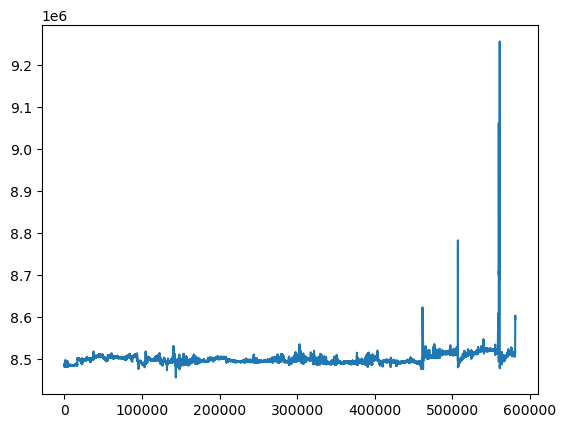

In [7]:
y = df.green1.iloc[600:].to_numpy()
plt.plot(y)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# --- 这里为了演示，我生成了随机伪数据。在实际使用时，请替换回你的 df 提取逻辑 ---

# y1 = np.random.randn(10000).cumsum()
# y2 = np.random.randn(10000).cumsum() * 0.5

col1 = 'green1'
col2 = 'ir1' 
y1 = -df[col1].astype(float).values
y2 = -df[col2].astype(float).values 
# 注意：移除了外层的 out = widgets.Output()

def plot_dual_zoom(start, window):
    # 注意：移除了 with out: 和 out.clear_output(wait=True)
    # 因为下面使用的 interactive_output 会自动并且更高效地处理画布的清理和刷新
    
    end = min(start + window, len(y1))
    t = np.arange(start, end) / 100.0  # 假设采样率为 100Hz
    
    # 防御性编程：如果数据为空，直接返回，避免 matplotlib 报错
    if start >= len(y1) or window <= 0:
        return

    # 创建主画布和左侧 Y 轴 (ax1)
    fig, ax1 = plt.subplots(figsize=(15, 5))
    
    # 核心：克隆 x 轴，创建一个共享 X 轴但独立 Y 轴的 ax2 (右侧 Y 轴)
    ax2 = ax1.twinx() 
    
    current_y1 = y1[start:end]
    current_y2 = y2[start:end]
    
    if len(current_y1) > 0 and len(current_y2) > 0:
        # 绘制左轴曲线 (绿色)
        line1 = ax1.plot(t, current_y1, '-', color='#2ca02c', linewidth=1.5, alpha=0.9, label=f'Raw {col1}')
        y1_min, y1_max = np.nanmin(current_y1), np.nanmax(current_y1)
        pad1 = (y1_max - y1_min) * 0.1 if y1_max != y1_min else 1
        ax1.set_ylim([y1_min - pad1, y1_max + pad1])
        
        # 绘制右轴曲线 (红色)
        line2 = ax2.plot(t, current_y2, '-', color='#d62728', linewidth=1.5, alpha=0.9, label=f'Raw {col2}')
        y2_min, y2_max = np.nanmin(current_y2), np.nanmax(current_y2)
        pad2 = (y2_max - y2_min) * 0.1 if y2_max != y2_min else 1
        ax2.set_ylim([y2_min - pad2, y2_max + pad2])
        
        # 合并两个轴的图例 (Legend)
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc='upper right')

    # 图表视觉与标签设置
    ax1.set_title(f'Dual Channel Viewer [{col1} & {col2}]: {start} ~ {end} ({window/100:.1f}s)', fontweight='bold')
    ax1.set_xlabel('Time (s)')
    
    # 将 Y 轴的文字和刻度颜色与曲线颜色对应，防止看混
    ax1.set_ylabel(f'{col1} Amplitude', color='#2ca02c', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#2ca02c')
    
    ax2.set_ylabel(f'{col2} Amplitude', color='#d62728', fontweight='bold')
    ax2.tick_params(axis='y', labelcolor='#d62728')
    
    # 只给主轴加网格
    ax1.grid(True, linestyle='--', alpha=0.4) 
    
    plt.tight_layout()
    plt.show()
    
    # 必须手动关闭
    plt.close(fig) 

# 修复核心1：增加 continuous_update=False
# 这样只有在你松开鼠标时，才会触发一次绘图，彻底解决卡死问题
start_slider = widgets.IntSlider(
    min=0, max=max(0, len(y1)-200), step=100, value=0, 
    description='start idx', continuous_update=False
)
window_slider = widgets.IntSlider(
    min=200, max=10000, step=200, value=1000, 
    description='window', continuous_update=False
)

# 修复核心2：让 interactive_output 自动生成并返回正确的 out 容器
out = widgets.interactive_output(plot_dual_zoom, {'start': start_slider, 'window': window_slider})

# 绑定交互并显示
ui = widgets.VBox([start_slider, window_slider, out])
display(ui)

In [9]:
acc_col = ["accX", "accY", "accZ", "motion"]
df[acc_col]

,accX,accY,accZ,motion
0,-200.0,-2076.0,156.0,2091.437783
1,-184.0,-2064.0,156.0,2078.049085
2,-100.0,-2004.0,136.0,2011.097213
3,-84.0,-1988.0,148.0,1995.270408
4,-84.0,-1984.0,140.0,1990.706407
...,...,...,...,...
581705,-816.0,684.0,-1592.0,1915.248287
581706,-816.0,684.0,-1592.0,1915.248287
581707,-816.0,684.0,-1592.0,1915.248287
581708,-816.0,684.0,-1592.0,1915.248287


<Axes: >

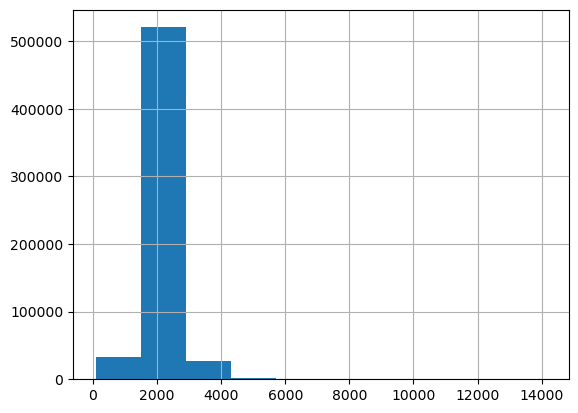

In [10]:
df.motion.hist()

<Axes: >

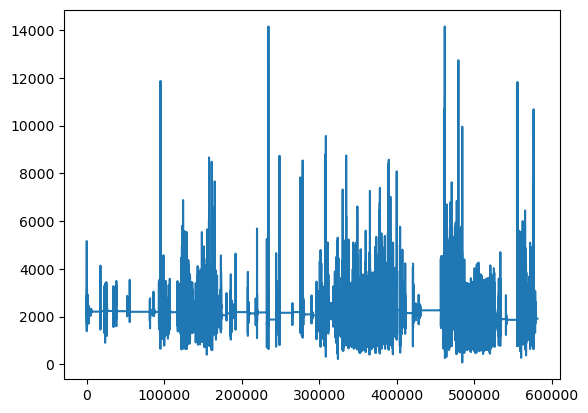

In [11]:
df.motion.plot()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# 1. 设定要目标列（只保留 green1）
col1 = 'green1'

# 安全提取单列数据
y1 = -df[col1].astype(float).values

def plot_single_zoom(start, window):
    end = min(start + window, len(y1))
    t = np.arange(start, end) / 100.0  # 假设采样率为 100Hz
    
    # 防御性编程：如果数据为空，直接返回，避免 matplotlib 报错
    if start >= len(y1) or window <= 0:
        return

    # 创建主画布（去掉了 twinx 双轴逻辑）
    fig, ax1 = plt.subplots(figsize=(15, 5))
    
    current_y1 = y1[start:end]
    
    if len(current_y1) > 0:
        # 绘制曲线 (绿色)
        ax1.plot(t, current_y1, '-', color='#2ca02c', linewidth=1.5, alpha=0.9, label=f'Raw {col1}')
        
        # 动态计算并设置 Y 轴范围
        y1_min, y1_max = np.nanmin(current_y1), np.nanmax(current_y1)
        pad1 = (y1_max - y1_min) * 0.1 if y1_max != y1_min else 1
        ax1.set_ylim([y1_min - pad1, y1_max + pad1])
        
        # 显示图例
        ax1.legend(loc='upper right')

    # 图表视觉与标签设置
    ax1.set_title(f'Single Channel Viewer [{col1}]: {start} ~ {end} ({window/100:.1f}s)', fontweight='bold')
    ax1.set_xlabel('Time (s)')
    
    # 将 Y 轴的文字和刻度颜色与曲线颜色对应
    ax1.set_ylabel(f'{col1} Amplitude', color='#2ca02c', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#2ca02c')
    
    # 添加网格线
    ax1.grid(True, linestyle='--', alpha=0.4) 
    
    plt.tight_layout()
    plt.show()
    
    # 手动关闭画布防止内存泄漏
    plt.close(fig) 

# 创建滑条 (保持 continuous_update=False 防止拖动时卡死)
start_slider = widgets.IntSlider(
    min=0, max=max(0, len(y1)-200), step=100, value=0, 
    description='start idx', continuous_update=False
)
window_slider = widgets.IntSlider(
    min=200, max=10000, step=200, value=1000, 
    description='window', continuous_update=False
)

# 让 interactive_output 自动管理输出隔离区
out = widgets.interactive_output(plot_single_zoom, {'start': start_slider, 'window': window_slider})

# 绑定交互并显示
ui = widgets.VBox([start_slider, window_slider, out])
display(ui)

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# 1. 设定目标列与提取数据 (假设 df 已经存在)
col1 = 'green1'
y1 = -df[col1].astype(float).values

# 2. 定义一维卡尔曼滤波函数
def kalman_smooth_1d(z, Q=1e-4, R=0.05):
    n_iter = len(z)
    x_hat = np.zeros(n_iter)
    P = np.zeros(n_iter)
    x_hat_minus = np.zeros(n_iter)
    P_minus = np.zeros(n_iter)
    K = np.zeros(n_iter)
    
    x_hat[0] = z[0]
    P[0] = 1.0
    
    for k in range(1, n_iter):
        x_hat_minus[k] = x_hat[k-1]
        P_minus[k] = P[k-1] + Q
        
        K[k] = P_minus[k] / (P_minus[k] + R)
        x_hat[k] = x_hat_minus[k] + K[k] * (z[k] - x_hat_minus[k])
        P[k] = (1 - K[k]) * P_minus[k]
        
    return x_hat

# 3. 核心绘图回调函数
def plot_single_zoom_with_kalman(start, window, q_val, r_val):
    end = min(start + window, len(y1))
    t = np.arange(start, end) / 100.0  # 假设采样率为 100Hz
    
    if start >= len(y1) or window <= 0:
        return

    fig, ax1 = plt.subplots(figsize=(15, 5))
    
    # 截取当前窗口的原始数据
    current_y1 = y1[start:end]
    
    if len(current_y1) > 0:
        # 实时计算当前窗口的卡尔曼滤波
        # 注意：为了更严谨避免边缘初始化的跳变，实际工程中可以对整个 y1 滤波后截取，
        # 但在探索阶段，对窗口数据实时计算响应更快。
        filtered_y1 = kalman_smooth_1d(current_y1, Q=q_val, R=r_val)

        # 绘制原始曲线 (浅绿色，带透明度)
        ax1.plot(t, current_y1, '-', color='#2ca02c', linewidth=1.0, alpha=0.6, label=f'Raw {col1}')
        
        # 绘制卡尔曼平滑曲线 (深红色，加粗)
        ax1.plot(t, filtered_y1, '-', color='#d62728', linewidth=2.0, alpha=0.9, label=f'Kalman Filtered')
        
        y1_min, y1_max = np.nanmin(current_y1), np.nanmax(current_y1)
        pad1 = (y1_max - y1_min) * 0.1 if y1_max != y1_min else 1
        ax1.set_ylim([y1_min - pad1, y1_max + pad1])
        ax1.legend(loc='upper right')

    ax1.set_title(f'PPG Viewer [{col1}]: {start} ~ {end} (Q={q_val:.5f}, R={r_val:.3f})', fontweight='bold')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel(f'{col1} Amplitude', color='#2ca02c', fontweight='bold')
    ax1.tick_params(axis='y', labelcolor='#2ca02c')
    ax1.grid(True, linestyle='--', alpha=0.4) 
    
    plt.tight_layout()
    plt.show()
    plt.close(fig) 

# 4. 创建交互组件
start_slider = widgets.IntSlider(
    min=0, max=max(0, len(y1)-200), step=100, value=0, 
    description='Start Idx', continuous_update=False
)
window_slider = widgets.IntSlider(
    min=200, max=10000, step=200, value=1000, 
    description='Window', continuous_update=False
)
# 新增 Q 和 R 滑块
q_slider = widgets.FloatLogSlider(
    value=1e-4, base=10, min=-6, max=-2, step=0.5, 
    description='Process Noise (Q)', continuous_update=False
)
r_slider = widgets.FloatSlider(
    value=0.05, min=0.001, max=0.5, step=0.01, 
    description='Meas Noise (R)', continuous_update=False
)

# 绑定并显示
out = widgets.interactive_output(
    plot_single_zoom_with_kalman, 
    {'start': start_slider, 'window': window_slider, 'q_val': q_slider, 'r_val': r_slider}
)

# 优化布局：将滑块分成两排
ui = widgets.VBox([
    widgets.HBox([start_slider, window_slider]), 
    widgets.HBox([q_slider, r_slider]), 
    out
])
display(ui)

In [14]:
import numpy as np

def fhan(x1, x2, r, h):
    """韩氏最速控制综合函数"""
    d = r * h * h
    a0 = h * x2
    y = x1 + a0
    
    a1 = np.sqrt(d * (d + 8 * np.abs(y)))
    a2 = a0 + np.sign(y) * (a1 - d) / 2.0
    
    sy = (np.sign(y + d) - np.sign(y - d)) / 2.0
    a = (a0 + y - a2) * sy + a2
    
    sa = (np.sign(a + d) - np.sign(a - d)) / 2.0
    u = -r * (a / d - np.sign(a)) * sa - r * np.sign(a)
    return u

def tracking_differentiator(v, fs=100.0, r=50.0, h0_multiple=2.0):
    """
    非线性跟踪微分器 (NLTD) 处理一维信号
    :param v: 原始带噪信号
    :param fs: 采样率 (Hz)
    :param r: 速度因子 (控制跟踪速度，PPG通常在 10~200 之间调试)
    :param h0_multiple: 滤波因子倍数 (h0 = h0_multiple * h，通常取 1.0 ~ 5.0)
    :return: x1 (平滑后的信号), x2 (平滑后信号的一阶导数)
    """
    n = len(v)
    h = 1.0 / fs
    h0 = h0_multiple * h
    
    x1 = np.zeros(n)
    x2 = np.zeros(n)
    
    # 初始化状态
    x1[0] = v[0]
    x2[0] = 0.0
    
    for k in range(n - 1):
        u = fhan(x1[k] - v[k], x2[k], r, h0)
        x1[k+1] = x1[k] + h * x2[k]
        x2[k+1] = x2[k] + h * u
        
    return x1, x2

# --- 调用示例 ---
# y1 是你提取的 -df['green1']
smoothed_ppg, derivative_ppg = tracking_differentiator(y1, fs=100.0, r=80.0, h0_multiple=3.0)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from numba import jit  # 新增：引入 JIT 编译加速

# 每次重新运行该单元格时，强制清理残留的图表和内存
plt.close('all') 

# 1. 设定目标列与提取数据 (假设 df 已经存在)
col1 = 'green1'
# 安全提取单列数据
y1_raw = -df[col1].astype(float).values

# 极简 Z-score 标准化
y1_mean = np.nanmean(y1_raw)
y1_std = np.nanstd(y1_raw)
y1 = (y1_raw - y1_mean) / (y1_std + 1e-8)  

fs = 100.0  

# ---------------------------------------------------------
# 2. 核心算法：引入 @jit(nopython=True) 进行 C 级加速
# ---------------------------------------------------------
@jit(nopython=True)
def fhan(x1, x2, r, h):
    """韩氏最速控制综合函数"""
    d = r * h * h
    a0 = h * x2
    y = x1 + a0
    a1 = np.sqrt(d * (d + 8.0 * np.abs(y)))
    a2 = a0 + np.sign(y) * (a1 - d) / 2.0
    sy = (np.sign(y + d) - np.sign(y - d)) / 2.0
    a = (a0 + y - a2) * sy + a2
    sa = (np.sign(a + d) - np.sign(a - d)) / 2.0
    u = -r * (a / d - np.sign(a)) * sa - r * np.sign(a)
    return u

@jit(nopython=True)
def tracking_differentiator(v, fs=100.0, r=80.0, h0_multiple=3.0):
    n = len(v)
    h = 1.0 / fs
    h0 = h0_multiple * h
    x1 = np.zeros(n)
    x2 = np.zeros(n)
    
    x1[0] = v[0]
    for k in range(n - 1):
        u = fhan(x1[k] - v[k], x2[k], r, h0)
        x1[k+1] = x1[k] + h * x2[k]
        x2[k+1] = x2[k] + h * u
    return x1, x2

# ---------------------------------------------------------
# 3. 核心绘图回调函数 
# ---------------------------------------------------------
def plot_td_interactive(start, window, r_val, h0_mult):
    end = min(start + window, len(y1))
    t = np.arange(start, end) / fs
    
    if start >= len(y1) or window <= 0:
        return

    current_y1 = y1[start:end]
    if len(current_y1) == 0:
        return
        
    # Numba 加速后，计算属于毫秒级
    x1, x2 = tracking_differentiator(current_y1, fs=fs, r=r_val, h0_multiple=h0_mult)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
    
    ax1.plot(t, current_y1, '-', color='#2ca02c', linewidth=1.0, alpha=0.8, label=f'Raw {col1}')
    ax1.plot(t, x1, '-', color='#d62728', linewidth=2.0, alpha=0.9, label='TD Smoothed (x1)')
    
    y1_min, y1_max = np.nanmin(current_y1), np.nanmax(current_y1)
    pad1 = (y1_max - y1_min) * 0.1 if y1_max != y1_min else 1
    ax1.set_ylim([y1_min - pad1, y1_max + pad1])
    ax1.set_title(f'TD Viewer [{col1}]: {start} ~ {end} (r={r_val}, h0={h0_mult}h)', fontweight='bold')
    ax1.set_ylabel('Amplitude (Z-score)', color='#2ca02c', fontweight='bold')
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle='--', alpha=0.4)
    
    ax2.plot(t, x2, '-', color='#1f77b4', linewidth=1.5, label='Derivative (x2)')
    ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
    
    ax2.set_xlabel('Time (s)')
    ax2.set_ylabel('Velocity (dx/dt)', color='#1f77b4', fontweight='bold')
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle='--', alpha=0.4)
    
    plt.tight_layout()
    plt.show()
    
    # 强制回收画布资源
    plt.close(fig)

# ---------------------------------------------------------
# 4. 创建交互组件
# ---------------------------------------------------------
start_slider = widgets.IntSlider(
    min=0, max=max(0, len(y1)-200), step=100, value=0, 
    description='Start Idx', continuous_update=False
)
window_slider = widgets.IntSlider(
    min=200, max=10000, step=200, value=1000, 
    description='Window', continuous_update=False
)
r_slider = widgets.FloatSlider(
    value=0.1, min=0.1, max=500.0, step=0.2, 
    description='Speed (r)', continuous_update=False
)
h0_slider = widgets.FloatSlider(
    value=3.0, min=1.0, max=10.0, step=0.5, 
    description='Filter (h0_mult)', continuous_update=False
)

# 使用 Output 控件专门管理图形输出，防止重绘闪烁和堆叠
out = widgets.interactive_output(
    plot_td_interactive, 
    {'start': start_slider, 'window': window_slider, 'r_val': r_slider, 'h0_mult': h0_slider}
)

ui = widgets.VBox([
    widgets.HBox([start_slider, window_slider]), 
    widgets.HBox([r_slider, h0_slider]), 
    out
])

display(ui)

In [16]:
## import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.ndimage import gaussian_filter1d
from matplotlib.figure import Figure 

# 1. 设定目标列与提取数据 
col1 = 'green1'
try:
    y1_raw = -df[col1].astype(float).values
except NameError:
    print("请先确保 df 已经被定义并加载了数据！")
    y1_raw = np.random.randn(5000) 

# 极简 Z-score 标准化
y1_mean = np.nanmean(y1_raw)
y1_std = np.nanstd(y1_raw)
y1 = (y1_raw - y1_mean) / (y1_std + 1e-8)  

fs = 100.0  

# ---------------------------------------------------------
# 2. 交互组件初始化 (新增两个 Sigma 控制器)
# ---------------------------------------------------------
start_slider = widgets.IntSlider(min=0, max=max(0, len(y1)-200), step=100, value=0, description='Start Idx', continuous_update=False)
window_slider = widgets.IntSlider(min=200, max=10000, step=200, value=1000, description='Window', continuous_update=False)

# sigma_base 用于提取宏观基线 (值很大)
sigma_base_slider = widgets.FloatSlider(value=50.0, min=10.0, max=200.0, step=5.0, description=r'$\sigma$ Baseline', continuous_update=False)
# sigma_pulse 用于去除微小毛刺 (值很小)
sigma_pulse_slider = widgets.FloatSlider(value=2.0, min=0.5, max=10.0, step=0.5, description=r'$\sigma$ Pulse', continuous_update=False)

out = widgets.Output()

# ---------------------------------------------------------
# 3. 核心绘图函数：双趟高斯滤波提取法
# ---------------------------------------------------------
def update_plot(*args):
    start = start_slider.value
    window = window_slider.value
    sigma_base = sigma_base_slider.value
    sigma_pulse = sigma_pulse_slider.value
    
    end = min(start + window, len(y1))
    t = np.arange(start, end) / fs
    
    if start >= len(y1) or window <= 0: return
    current_y1 = y1[start:end]
    if len(current_y1) == 0: return
        
    # --- 核心算法：带通解耦 ---
    # 1. 提取极低频基线
    baseline = gaussian_filter1d(current_y1, sigma=sigma_base)
    # 2. 去趋势：原始信号减去基线，把信号拉平到 0 刻度
    detrended = current_y1 - baseline
    # 3. 提取纯净脉搏：对拉平后的信号进行轻微平滑，去除高频毛刺
    clean_pulse = gaussian_filter1d(detrended, sigma=sigma_pulse)
    
    # 顺便求个纯净的一阶导数备用
    pulse_derivative = gaussian_filter1d(detrended, sigma=sigma_pulse, order=1) * fs

    with out:
        clear_output(wait=True) 
        fig = Figure(figsize=(15, 10))
        
        # 图 1：原始信号 vs 提取出的缓慢基线
        ax1 = fig.add_subplot(311)
        ax1.plot(t, current_y1, '-', color='#2ca02c', linewidth=1.0, alpha=0.5, label=f'Raw {col1}')
        ax1.plot(t, baseline, '--', color='#1f77b4', linewidth=2.0, label=rf'Extracted Baseline ($\sigma$={sigma_base})')
        ax1.set_title(f'Step 1: Baseline Drift Extraction', fontweight='bold')
        ax1.legend(loc='upper right')
        ax1.grid(True, linestyle='--', alpha=0.4)
        
        # 图 2：去趋势后纯净的脉搏波 (核心结果)
        ax2 = fig.add_subplot(312, sharex=ax1)
        ax2.axhline(0, color='gray', linestyle='-', alpha=0.3)
        # 画出带有毛刺的去基线信号作为背景对比
        ax2.plot(t, detrended, '-', color='gray', linewidth=1.0, alpha=0.9, label='Detrended (Noisy)')
        # 画出最终极其平滑且无相位偏移的完美脉搏波
        ax2.plot(t, clean_pulse, '-', color='#d62728', linewidth=2.0, label=rf'Clean Pulse ($\sigma$={sigma_pulse})')
        ax2.set_title('Step 2: Clean Pulse Recovery (Zero Phase Shift)', fontweight='bold')
        ax2.set_ylabel('Amplitude', fontweight='bold')
        ax2.legend(loc='upper right')
        ax2.grid(True, linestyle='--', alpha=0.4)

        # 图 3：纯净脉搏波的一阶导数
        ax3 = fig.add_subplot(313, sharex=ax1)
        ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)
        ax3.plot(t, pulse_derivative, '-', color='#9467bd', linewidth=1.5, label='Pulse Derivative (dx/dt)')
        ax3.set_xlabel('Time (s)')
        ax3.set_ylabel('Velocity', color='#9467bd', fontweight='bold')
        ax3.legend(loc='upper right')
        ax3.grid(True, linestyle='--', alpha=0.4)
        
        fig.tight_layout()
        display(fig)

start_slider.observe(update_plot, 'value')
window_slider.observe(update_plot, 'value')
sigma_base_slider.observe(update_plot, 'value')
sigma_pulse_slider.observe(update_plot, 'value')

ui = widgets.VBox([
    widgets.HBox([start_slider, window_slider]), 
    widgets.HBox([sigma_base_slider, sigma_pulse_slider]), 
    out
])

display(ui)
update_plot()